# 💊 Anti-Cancer Drug Response Prediction using Gene Expression 

We are building a machine learning pipeline to predict how sensitive various cancer cell lines are to different drugs (IC50 values) using simulated gene expression data.


 # 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns


 # 📁 Step 2: Load Dataset

In [2]:
file_path="D:/BE-project/datasets/GDSC_DATASET.csv"

In [3]:
df=pd.read_csv(file_path)

# 🔍 Step 3: Preview Dataset

In [4]:
df.head(20)

,COSMIC_ID,0,0.1,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication
5,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
6,687452,5637,BLCA,1003,Camptothecin,-2.632632,0.834067,-0.203221,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TOP1,DNA replication
7,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
8,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
9,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication


# ✅ Step 4: Clean Missing Data

In [5]:
df=df.dropna(subset=['DRUG_NAME', 'LN_IC50', 'AUC', 'GDSC Tissue descriptor 2'])


# 🧬 Step 5: Simulate Gene Expression

In [6]:
# Simulate gene expression data (replace with real genes if you have)
np.random.seed(42)
gene_expr_all = pd.DataFrame(np.random.rand(len(df), 2000), columns=[f"Gene_{i}" for i in range(2000)])

# 🔢 Step 6: Select Drugs and Initialize Prediction

In [7]:
# Store final predicted IC50 values
all_predictions = []

# Select top 12 drugs based on sample size
top_12_drugs = df['DRUG_NAME'].value_counts().head(12).index.tolist()

# Use this in your loop
unique_drugs = top_12_drugs

# 🔁 Step 7: Loop Over Each Drug

In [8]:
for drug in unique_drugs:
    sub_df = df[df['DRUG_NAME'] == drug].dropna()
    if len(sub_df) < 30:
        continue  # skip small samples

    sub_df = sub_df.reset_index(drop=True)
    gene_expr = gene_expr_all.iloc[:len(sub_df)].copy()
    gene_expr['IC50'] = sub_df['LN_IC50'].values


# 🧪 Step 8: Feature Selection Using Pearson Correlation

In [9]:
# Feature pre-selection using Pearson correlation
selected_genes = []

for gene in gene_expr.columns[:-1]:
    _, p = pearsonr(gene_expr[gene], gene_expr["IC50"])
    if p < 0.05:
        selected_genes.append(gene)

    # Skip drug if no significant genes
    if not selected_genes:
        continue

# Final features and labels
X = gene_expr[selected_genes]
y = gene_expr["IC50"]



# ⚙️ Step 9: Scale Data and Train Model

In [10]:
 # Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train ElasticNet model
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model = ElasticNetCV(l1_ratio=0.5, cv=5)
model.fit(X_train, y_train)

# Predict on full data
predicted_ic50 = model.predict(X_scaled)



# 💾 Step 10: Store Predictions

In [11]:
# Add prediction to dataframe
pred_df = sub_df.copy()
pred_df['Predicted_IC50'] = predicted_ic50
pred_df['Selected_Genes'] = len(selected_genes)
all_predictions.append(pred_df)

# 📊 Step 11: Combine All Predictions



In [12]:
# Combine all predictions
final_df = pd.concat(all_predictions)

# Group by drug and cancer type, take mean of predicted IC50
grouped = final_df.groupby(['DRUG_NAME', 'GDSC Tissue descriptor 2'])['Predicted_IC50'].mean().reset_index()

# Find most sensitive cancer types (lowest IC50 per drug)
top_by_drug = (
    grouped.sort_values(['DRUG_NAME', 'Predicted_IC50'])
    .groupby('DRUG_NAME')
    .head(5)
    .reset_index(drop=True)
)

# Show results
print("\n📊 Top Cancer Types Per Drug Based on Predicted IC50 (ElasticNet):")
print(top_by_drug)


📊 Top Cancer Types Per Drug Based on Predicted IC50 (ElasticNet):
     DRUG_NAME        GDSC Tissue descriptor 2  Predicted_IC50
0  Palbociclib   haematopoietic_neoplasm other        2.454892
1  Palbociclib  lymphoblastic_T_cell_leukaemia        2.485882
2  Palbociclib         lymphoid_neoplasm other        2.708461
3  Palbociclib          lymphoblastic_leukemia        2.727537
4  Palbociclib                 B_cell_lymphoma        2.755747


In [13]:
for drug in unique_drugs:
    sub_df = df[df['DRUG_NAME'] == drug].dropna()
    if len(sub_df) < 30:
        continue  # skip small samples

    sub_df = sub_df.reset_index(drop=True)
    gene_expr = gene_expr_all.iloc[:len(sub_df)].copy()
    gene_expr['IC50'] = sub_df['LN_IC50'].values

    # Feature pre-selection using Pearson correlation
    selected_genes = []
    for gene in gene_expr.columns[:-1]:
        _, p = pearsonr(gene_expr[gene], gene_expr["IC50"])
        if p < 0.05:
            selected_genes.append(gene)

    if not selected_genes:
        continue

    X = gene_expr[selected_genes]
    y = gene_expr["IC50"]

    # Normalize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train ElasticNet model
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    model = ElasticNetCV(l1_ratio=0.5, cv=5)
    model.fit(X_train, y_train)

    # Predict on full data
    predicted_ic50 = model.predict(X_scaled)

    # Add prediction to dataframe
    pred_df = sub_df.copy()
    pred_df['Predicted_IC50'] = predicted_ic50
    pred_df['Selected_Genes'] = len(selected_genes)
    all_predictions.append(pred_df)

# Combine all predictions
final_df = pd.concat(all_predictions)

# Group by drug and cancer type, take mean of predicted IC50
grouped = final_df.groupby(['DRUG_NAME', 'GDSC Tissue descriptor 2'])['Predicted_IC50'].mean().reset_index()

# Find most sensitive cancer types (lowest IC50 per drug)
top_by_drug = (
    grouped.sort_values(['DRUG_NAME', 'Predicted_IC50'])
    .groupby('DRUG_NAME')
    .head(8)
    .reset_index(drop=True)
)

# Show results
print("\n📊 Top Cancer Types Per Drug Based on Predicted IC50 (ElasticNet):")
print(top_by_drug)


📊 Top Cancer Types Per Drug Based on Predicted IC50 (ElasticNet):
         DRUG_NAME        GDSC Tissue descriptor 2  Predicted_IC50
0   5-Fluorouracil                 B_cell_lymphoma        3.399538
1   5-Fluorouracil  lymphoblastic_T_cell_leukaemia        3.704774
2   5-Fluorouracil   haematopoietic_neoplasm other        3.790517
3   5-Fluorouracil                   adrenal_gland        3.815894
4   5-Fluorouracil         acute_myeloid_leukaemia        3.836223
..             ...                             ...             ...
83      Uprosertib                         myeloma        2.425496
84      Uprosertib                 B_cell_lymphoma        2.457793
85      Uprosertib                     endometrium        2.476243
86      Uprosertib          lymphoblastic_leukemia        2.505833
87      Uprosertib  lymphoblastic_T_cell_leukaemia        2.537473

[88 rows x 3 columns]


# 🧠 Step 12: Visualize Predictions by Drug

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10896\3116593406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


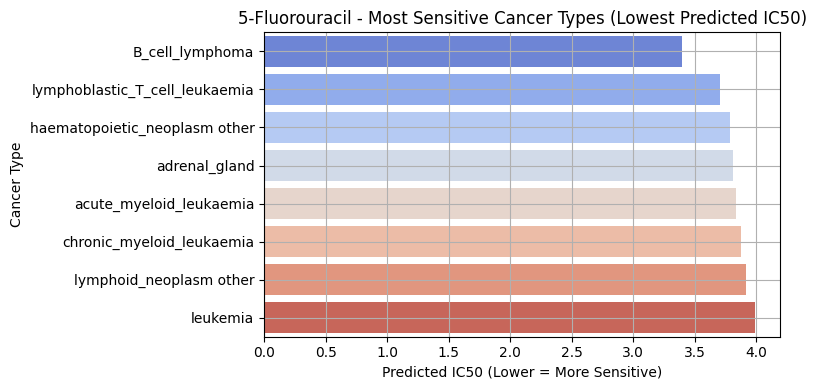

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10896\3116593406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


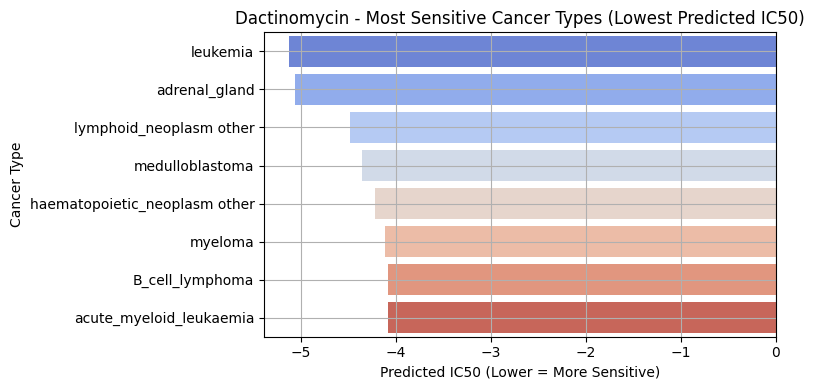

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10896\3116593406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


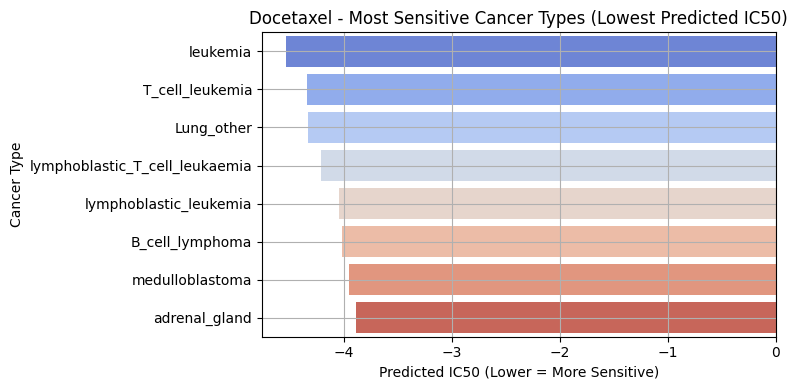

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10896\3116593406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


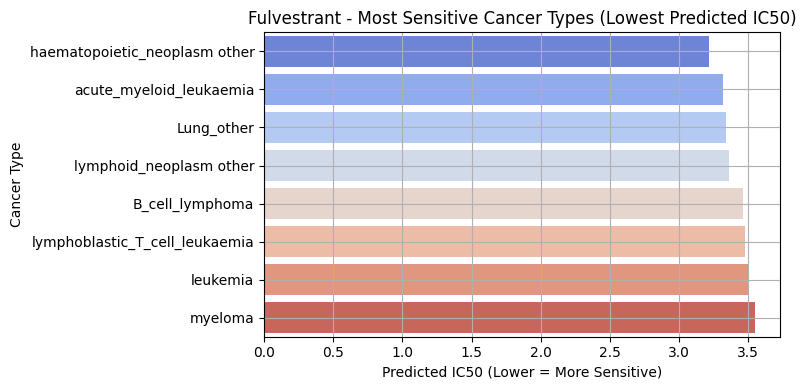

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10896\3116593406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


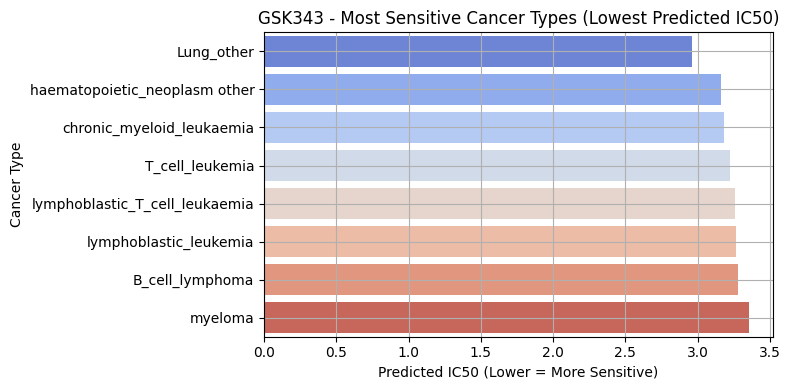

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10896\3116593406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


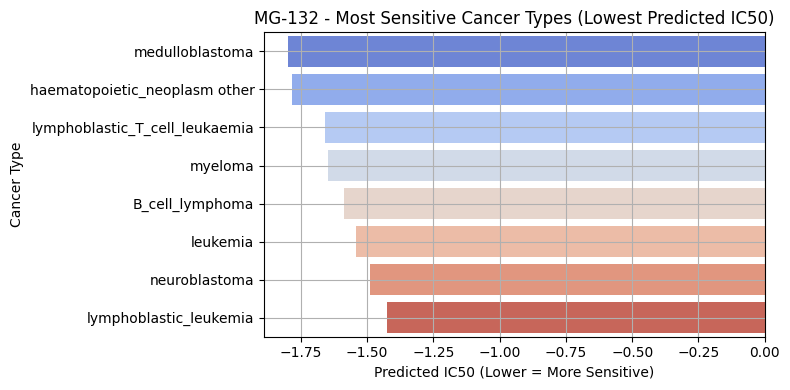

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10896\3116593406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


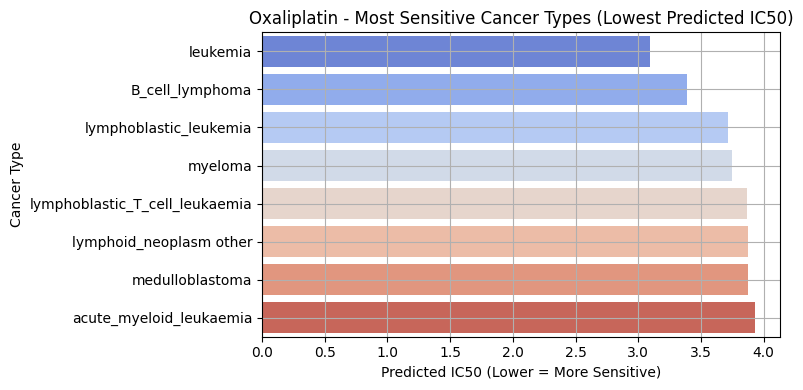

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10896\3116593406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


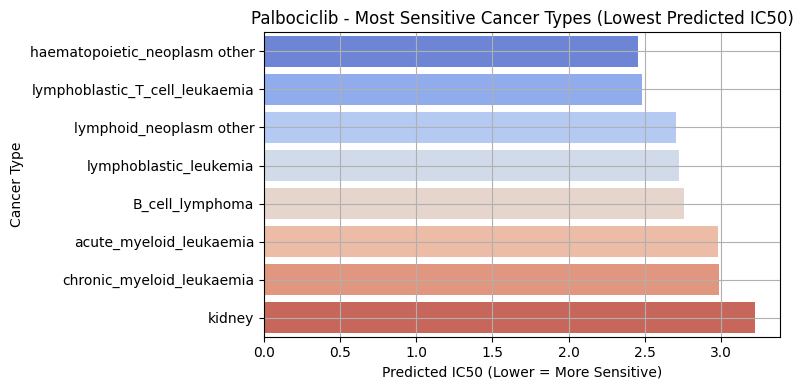

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10896\3116593406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


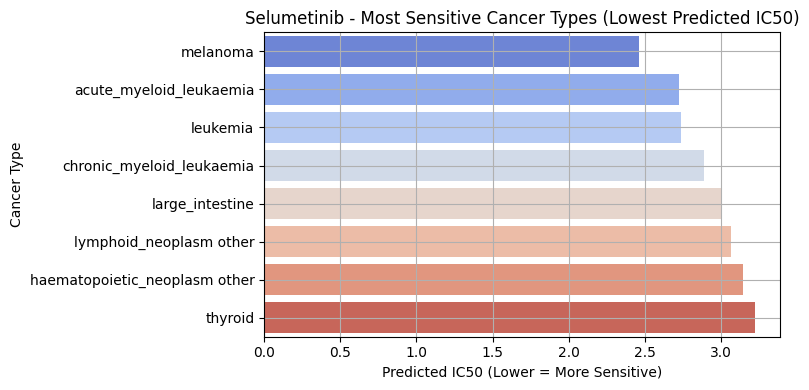

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10896\3116593406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


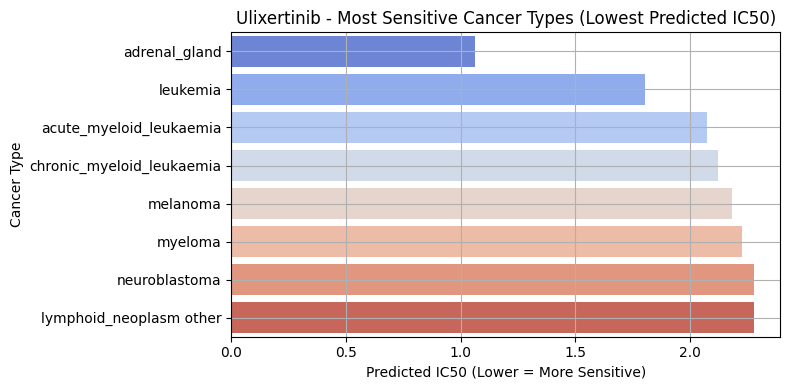

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10896\3116593406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


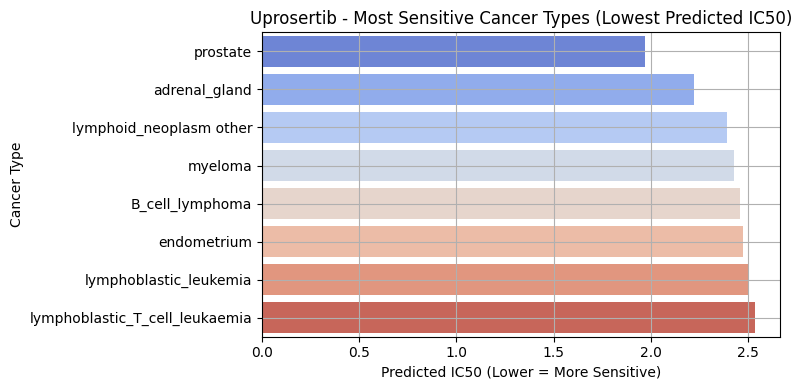

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot top cancer types (lowest IC50) for each drug
for drug in top_by_drug['DRUG_NAME'].unique():
    drug_df = top_by_drug[top_by_drug['DRUG_NAME'] == drug]

    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=drug_df,
        x='Predicted_IC50',
        y='GDSC Tissue descriptor 2',
        palette='coolwarm',
        orient='h'
    )

    plt.title(f"{drug} - Most Sensitive Cancer Types (Lowest Predicted IC50)")
    plt.xlabel("Predicted IC50 (Lower = More Sensitive)")
    plt.ylabel("Cancer Type")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


📘 Uprosertib:
   R² Score (IC50 prediction): 0.276
   Selected Genes: 102


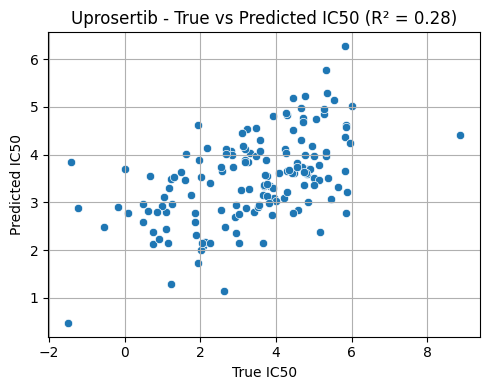

In [15]:
from sklearn.metrics import r2_score

# Calculate R² on test set
r2 = r2_score(y_test, model.predict(X_test))

# Print model performance
print(f"📘 {drug}:")
print(f"   R² Score (IC50 prediction): {r2:.3f}")
print(f"   Selected Genes: {len(selected_genes)}")

# Scatter plot: True vs Predicted IC50
plt.figure(figsize=(5, 4))
sns.scatterplot(x=y_test, y=model.predict(X_test))
plt.title(f"{drug} - True vs Predicted IC50 (R² = {r2:.2f})")
plt.xlabel("True IC50")
plt.ylabel("Predicted IC50")
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
# 📊 Final interpretation: Which drug is best for which cancer type?
summary_table = top_by_drug.sort_values("Predicted_IC50").reset_index(drop=True)

print("\n🔬 Final Summary: Most Effective Drugs by Cancer Type (Lowest Predicted IC50)\n")
for idx, row in summary_table.iterrows():
    print(f"👉 {row['DRUG_NAME']} is most effective for '{row['GDSC Tissue descriptor 2']}' (Predicted IC50: {row['Predicted_IC50']:.2f})")





🔬 Final Summary: Most Effective Drugs by Cancer Type (Lowest Predicted IC50)

👉 Dactinomycin is most effective for 'leukemia' (Predicted IC50: -5.13)
👉 Dactinomycin is most effective for 'adrenal_gland' (Predicted IC50: -5.06)
👉 Docetaxel is most effective for 'leukemia' (Predicted IC50: -4.53)
👉 Dactinomycin is most effective for 'lymphoid_neoplasm other' (Predicted IC50: -4.49)
👉 Dactinomycin is most effective for 'medulloblastoma' (Predicted IC50: -4.35)
👉 Docetaxel is most effective for 'T_cell_leukemia' (Predicted IC50: -4.34)
👉 Docetaxel is most effective for 'Lung_other' (Predicted IC50: -4.33)
👉 Dactinomycin is most effective for 'haematopoietic_neoplasm other' (Predicted IC50: -4.21)
👉 Docetaxel is most effective for 'lymphoblastic_T_cell_leukaemia' (Predicted IC50: -4.21)
👉 Dactinomycin is most effective for 'myeloma' (Predicted IC50: -4.11)
👉 Dactinomycin is most effective for 'B_cell_lymphoma' (Predicted IC50: -4.08)
👉 Dactinomycin is most effective for 'acute_myeloid_leuk

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10896\4203840067.py:23: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


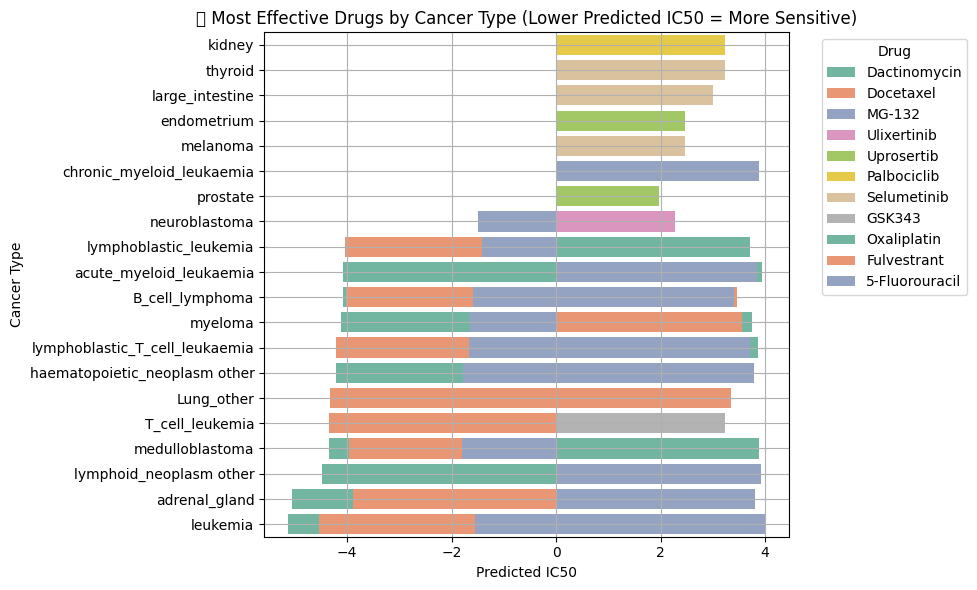

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort for clarity
summary_table = top_by_drug.sort_values("Predicted_IC50").reset_index(drop=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_table,
    x="Predicted_IC50",
    y="GDSC Tissue descriptor 2",
    hue="DRUG_NAME",
    dodge=False,
    palette="Set2"
)

plt.title("🔬 Most Effective Drugs by Cancer Type (Lower Predicted IC50 = More Sensitive)")
plt.xlabel("Predicted IC50")
plt.ylabel("Cancer Type")
plt.gca().invert_yaxis()  # Most sensitive at top
plt.legend(title="Drug", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()


In [18]:
# 1. Prepare predictions_df (if not already defined)
predictions_df = final_df[['DRUG_NAME', 'GDSC Tissue descriptor 2', 'Predicted_IC50']].copy()

# 2. Group by cancer type and drug, calculate average predicted IC50
cancer_wise_best_drug = predictions_df.groupby(
    ['GDSC Tissue descriptor 2', 'DRUG_NAME']
)['Predicted_IC50'].mean().reset_index()

# 3. For each cancer type, get the drug with the lowest predicted IC50
best_drug_per_cancer = cancer_wise_best_drug.sort_values(
    "Predicted_IC50"
).groupby("GDSC Tissue descriptor 2").first().reset_index()

# 4. Print in your requested format
print("\n🎯 Best Drug for Each Cancer Type (Lowest Predicted IC50):\n")
for idx, row in best_drug_per_cancer.iterrows():
    print(f"✅ {row['GDSC Tissue descriptor 2']} responds best to {row['DRUG_NAME']} (Predicted IC50: {row['Predicted_IC50']:.2f})")





🎯 Best Drug for Each Cancer Type (Lowest Predicted IC50):

✅ B_cell_lymphoma responds best to Dactinomycin (Predicted IC50: -4.08)
✅ Bladder responds best to Dactinomycin (Predicted IC50: -3.72)
✅ Lung_other responds best to Docetaxel (Predicted IC50: -4.33)
✅ T_cell_leukemia responds best to Docetaxel (Predicted IC50: -4.34)
✅ acute_myeloid_leukaemia responds best to Dactinomycin (Predicted IC50: -4.08)
✅ adrenal_gland responds best to Dactinomycin (Predicted IC50: -5.06)
✅ breast responds best to Dactinomycin (Predicted IC50: -3.41)
✅ cervix responds best to Dactinomycin (Predicted IC50: -3.88)
✅ chronic_myeloid_leukaemia responds best to Dactinomycin (Predicted IC50: -3.93)
✅ endometrium responds best to Dactinomycin (Predicted IC50: -3.06)
✅ glioma responds best to Dactinomycin (Predicted IC50: -3.75)
✅ haematopoietic_neoplasm other responds best to Dactinomycin (Predicted IC50: -4.21)
✅ head and neck responds best to Dactinomycin (Predicted IC50: -3.78)
✅ kidney responds best to 

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10896\2736357104.py:26: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


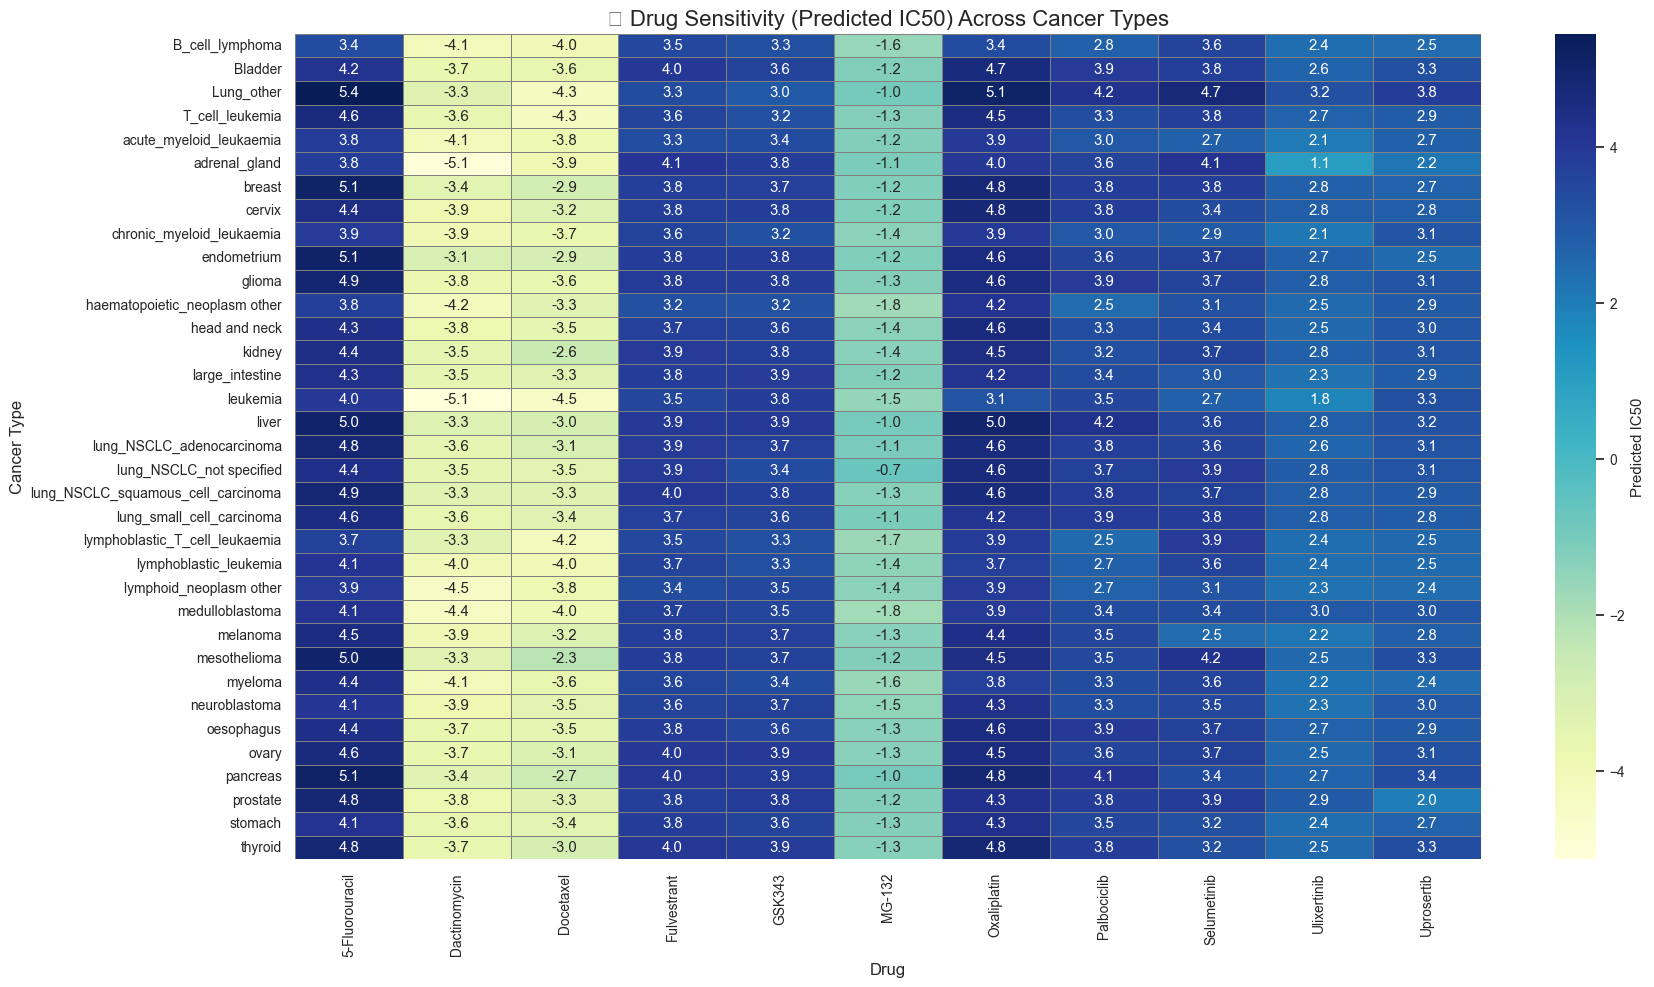

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Pivot the full IC50 matrix
heatmap_data = predictions_df.groupby(['GDSC Tissue descriptor 2', 'DRUG_NAME'])['Predicted_IC50'].mean().unstack()

# Plot heatmap
plt.figure(figsize=(18, 10))
sns.set(font_scale=0.9)

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor='gray',
    annot=True,
    fmt=".1f",
    cbar_kws={'label': 'Predicted IC50'},
)

plt.title("🔬 Drug Sensitivity (Predicted IC50) Across Cancer Types", fontsize=16)
plt.xlabel("Drug", fontsize=12)
plt.ylabel("Cancer Type", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
